In [1]:
import xarray as xr
import numpy as np
import re
import pandas as pd
import torch
from dask.distributed import Client

In [2]:
# client = Client(n_workers=24, threads_per_worker=4)
# client

In [3]:
# ANCILLARY FILE FOR HIMAWARI CMIC
ancil = xr.open_dataset('/g/data/ra22/satellite-products/arc/obs/himawari-ahi/fldk/latest/ancillary/00000000000000-P1S-ABOM_GEOM_SENSOR-PRJ_GEOS141_2000-HIMAWARI8-AHI.nc')
ancil = ancil.isel(time=0)

In [4]:
ds = xr.load_dataset('/g/data/ra22/satellite-products/arc/obs/himawari-ahi/fldk/latest/2024/01/01/0000/20240101000000-P1S-ABOM_BRF_B05-PRJ_GEOS141_2000-HIMAWARI9-AHI.nc')

In [53]:
def get_sat_reg(ancil, ds, lat_min, lat_max, lon_min, lon_max):
    reg = ancil.where(
        (ancil.lat > lat_min) & (ancil.lat < lat_max) & 
        (ancil.lon > lon_min) & (ancil.lon < lon_max),
        drop=True
    )
    return ds.sel(y=reg.y.values, x=reg.x.values)

In [55]:
ds_reg = get_sat_reg(ancil, ds, lat_min=-34, lat_max=-33, lon_min=151, lon_max=152)

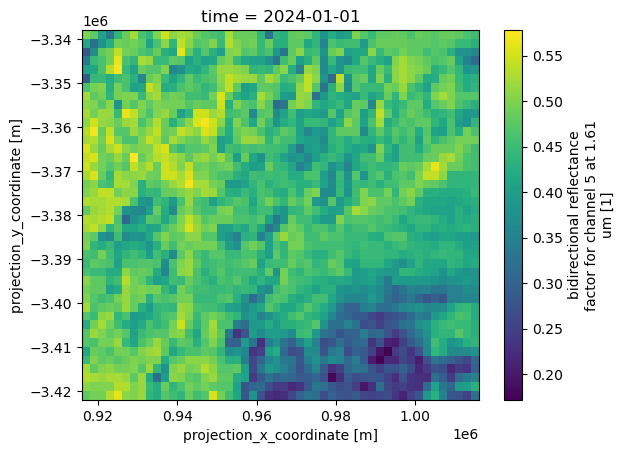

In [57]:
ds_reg.isel(time=0).channel_0005_brf.plot()

In [ ]:
def get_radiance_data(channel, time, region):
    '''
    Retrieve Himawari-8/9 radiance data from an individual channel for a certain time period and region.

    INPUTS
    channel (str): name of the AHI channel
    time (tuple, len=2): start and end time bounds to retrieve data for
    region (tuple, len=4): min and max values 
    '''
    lat_min, lat_max, lon_min, lon_max = region